# H1: Sentinel-1 vs SEPA pixel agreement, restricted to the eligible domain.
Reads only sepa_eligibility.gpkg -- never the raw SEPA shapefile.

Cinventiohn:
    reference = Sentinel-1 observed, prediction = SEPA modelled
    precision = TP/(TP+FP) : of SEPA's extent, how much S1 observed
    recall    = TP/(TP+FN) : of S1's detections, how much SEPA models
    The cascade calls these recall and precision respectively.

SEPA maps a return-period envelope, not this storm, so FN is mostly floodplain
that was never wet. CSI and lift are the defensible metrics; overall accuracy
is not (a "no flood everywhere" model scores >99%).

This the main hypothesis-testing script — H1. The code belwoi asks: where Sentinel-1 actually observed flooding in October 2023, how well does it agree with SEPA's modelled flood-hazard maps, and does that agreement break down in dense urban areas?

The setup rasterises three things onto the same 10 m grid: the S1 observed flood, SEPA's modelled extent, and the "eligible domain" (the ground the cascade decided was fair to assess, so slope, urban artefacts etc. are already handled upstream). It only reads the pre-computed eligibility layer, never the raw SEPA shapefile, so the comparison stays inside the domain the pipeline sanctioned. There's a hard gate that aborts if fewer than 95% of S1 detections fall inside that domain, which catches the classic failure of the flood raster and mask rasters coming from mismatched exports.

Metrics. It deliberately avoids overall accuracy, since SEPA maps a return-period envelope rather than this specific storm, most "false negatives" are just floodplain that never got wet, and a "no flood anywhere" model would score >99%. So it leans on CSI and on lift (observed overlap vs. what I'd expect from random placement), plus a normalised lift that's comparable across strata with different base rates. Then it slices everything by imperviousness: an overall stratum, dense-urban vs less-built-up, and a full decile breakdown to show exactly where detection skill collapses.

The statistical rigour: Confidence intervals come from bootstrapping 1 km blocks, not pixels , because neighbouring 10 m pixels are heavily autocorrelated and pixel-level intervals would be dishonestly tight. Both urban and rural strata are scored inside the same resampled blocks each iteration, so the urban-vs-rural difference gets a direct paired interval rather than eyeballing two separate ones. That difference-excludes-zero test is what actually licenses the headline claim about urban agreement being weaker.

Finally it runs a sensitivity check with no masking at all, so the gap between the masked and unmasked figures cleanly attributes how much is "the method excluded it" vs "the method looked and found nothing" — and exports metrics, deciles, per-source, bootstrap, and a 1 km disagreement grid for mapping.

In conclusion, this code measures how well satellite-observed flooding matches the official flood model inside the eligible area, tests whether that match falls apart in dense urban fabric, and does it with the right metrics and block-bootstrapped confidence intervals so the urban finding is statistically defensible rather than just a suggestive gap between point estimates.


In [ ]:
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
from shapely.ops import unary_union

# Setup
BASE = Path("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation")
GPKG = BASE / "cascade_outputs" / "sepa_eligibility.gpkg"
S1_TIF = BASE / "DATA/Sentinel-1_StudyArea/StudyArea_flood_extent_oct2023_v5_slope30_buf50.tif"
HRL_TIF = BASE / "DATA/StudyArea_hrl_imperviousness_2018.tif"
AOI_SHP = BASE / "study_area_10Kmbuffer_dissolved.shp"   

OUT = BASE
CRS = "EPSG:3035"
IMPERV_THRESH = 50        # dense-urban cut (%)
CELL = 1000               # metres, block size for the grid and bootstrap
N_BOOT = 1000
SEED = 42

rng = np.random.default_rng(SEED)
lines = []


def log(msg=""):
    print(msg)
    lines.append(msg)


# Metrics
def metrics(tp, fp, fn, tn):
    """
    Confusion cells -> reported metrics.

    lift = observed overlap / overlap expected if the same number of SEPA
    pixels were placed at random. Unlike CSI it does not shift when the
    analysis mask changes size. Its ceiling is 1/max(s1_frac, sepa_frac) and
    that ceiling differs between strata, so lift_norm is what to use for
    cross-stratum comparisons.
    """
    n = tp + fp + fn + tn
    if n == 0:
        return {}
    p, r = tp + fp, tp + fn                       # SEPA count, S1 count
    s1_frac, sepa_frac = r / n, p / n

    csi = tp / (tp + fp + fn) if (tp + fp + fn) else np.nan
    precision = tp / p if p else np.nan
    recall = tp / r if r else np.nan

    expected = p * s1_frac
    lift = tp / expected if expected > 0 else np.nan
    lift_max = 1 / max(s1_frac, sepa_frac) if max(s1_frac, sepa_frac) > 0 else np.nan
    lift_norm = (lift - 1) / (lift_max - 1) if lift_max and lift_max > 1 else np.nan

    return {
        "n_pixels": n, "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "CSI": csi, "precision": precision, "recall": recall,
        "lift": lift, "lift_max": lift_max, "lift_norm": lift_norm,
        "s1_frac": s1_frac, "sepa_frac": sepa_frac,
        "bias_sepa_minus_s1": sepa_frac - s1_frac,
    }


def score(s1, sepa, m):
    """Metrics for a boolean stratum mask."""
    a, b = s1[m], sepa[m]
    tp = int(np.count_nonzero(a & b))
    fp = int(np.count_nonzero(~a & b))
    fn = int(np.count_nonzero(a & ~b))
    return metrics(tp, fp, fn, a.size - tp - fp - fn)


def burn(geom, shape, transform):
    if geom.is_empty:
        return np.zeros(shape, bool)
    return rasterize([(geom, 1)], out_shape=shape, transform=transform,
                     fill=0, dtype=np.uint8).astype(bool)


# Load
log("=" * 70)
log("H1: SENTINEL-1 vs SEPA -- PIXEL AGREEMENT (eligible domain)")
log("=" * 70)

with rasterio.open(S1_TIF) as src:
    if src.crs.to_epsg() != 3035:
        raise RuntimeError(f"S1 raster must be EPSG:3035, found {src.crs}")
    band = src.read(1, masked=True)
    s1 = (np.where(band.mask, 0, band.filled(0)) >= 1)   # GEE selfMask: nodata == dry
    transform, shape = src.transform, src.shape
    pixel_m = abs(transform.a)

eligible = unary_union(gpd.read_file(GPKG, layer="eligible_domain").to_crs(CRS).geometry.values)
sepa_geom = unary_union(gpd.read_file(GPKG, layer="sepa_eligible").to_crs(CRS).geometry.values)
by_type = gpd.read_file(GPKG, layer="sepa_eligible_by_type").to_crs(CRS)
aoi = unary_union(gpd.read_file(AOI_SHP).to_crs(CRS).geometry.values)

mask = burn(eligible, shape, transform)
sepa = burn(sepa_geom, shape, transform)
aoi_mask = burn(aoi, shape, transform)

log(f"\nEligible domain : {eligible.area / 1e6:.2f} km2 "
    f"({100 * eligible.area / aoi.area:.1f}% of AOI), {int(mask.sum()):,} px")
log(f"SEPA eligible   : {sepa_geom.area / 1e6:.2f} km2, {int(sepa.sum()):,} px")

# Gatekeeping: The classifier's detections must sit inside the domain the cascade says
# it was allowed to examine. Below 95% means the flood raster and the mask
# rasters came from different GEE exports and nothing downstream is valid.
in_aoi = int(np.count_nonzero(s1 & aoi_mask))
in_mask = int(np.count_nonzero(s1 & mask))
retained = 100 * in_mask / in_aoi if in_aoi else 0
log(f"S1 detections   : {int(s1.sum()):,} total, {in_aoi:,} in AOI, "
    f"{in_mask:,} in eligible domain ({retained:.2f}%)")
if retained < 95:
    raise RuntimeError(f"Only {retained:.1f}% of S1 detections are in the eligible "
                       "domain -- flood raster and mask rasters are mismatched.")

# Imperviousness, resampled to the S1 grid if needed. HRL codes 254/255 as
# nodata; unfiltered those exceed every threshold and inflate the urban stratum.
with rasterio.open(HRL_TIF) as src:
    log(f"HRL native      : {src.shape}, {abs(src.transform.a):.0f} m pixels")
    if src.shape == shape and src.transform == transform:
        imperv = src.read(1).astype(np.float32)
    else:
        from rasterio.warp import Resampling, reproject
        imperv = np.zeros(shape, np.float32)
        reproject(rasterio.band(src, 1), imperv,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=transform, dst_crs=CRS,
                  resampling=Resampling.average)
valid = imperv <= 100

strata = {
    "overall": mask,
    "dense_urban": mask & valid & (imperv >= IMPERV_THRESH),
    "less_built_up": mask & valid & (imperv < IMPERV_THRESH),
}

# Retention Ceiling (computed by the cascade)
log("\n" + "-" * 70)
log("SEPA RETENTION -- the ceiling on agreement for each source")
log("-" * 70)
log(by_type[["flood_type", "area_raw_km2", "area_eligible_km2", "pct_eligible"]]
    .sort_values("flood_type").to_string(index=False))

# Headline metrics
log("\n" + "-" * 70)
log("METRICS BY STRATUM")
log("-" * 70)

rows = []
for name, m in strata.items():
    if m.sum() == 0:
        continue
    r = score(s1, sepa, m)
    r["stratum"] = name
    rows.append(r)
    log(f"\n{name}  ({int(m.sum()):,} px, {100 * m.sum() / mask.sum():.1f}% of domain)")
    log(f"  TP={r['TP']:,}  FP={r['FP']:,}  FN={r['FN']:,}  TN={r['TN']:,}")
    log(f"  CSI {r['CSI']:.4f}   lift {r['lift']:.2f} (max {r['lift_max']:.1f}, "
        f"norm {r['lift_norm']:.3f})")
    log(f"  precision {r['precision']:.4f}  recall {r['recall']:.4f}")
    log(f"  share of all S1 detections here: "
        f"{100 * (r['TP'] + r['FN']) / in_mask:.1f}%")

metrics_df = pd.DataFrame(rows).set_index("stratum")

# Impreviousness deciles show where detection skill collapses

log("\n" + "-" * 70)
log("BY IMPERVIOUSNESS DECILE")
log("-" * 70)
dec_rows = []
for lo in range(0, 100, 10):
    hi = lo + 10
    upper = (imperv <= hi) if hi == 100 else (imperv < hi)
    m = mask & valid & (imperv >= lo) & upper
    if m.sum() == 0:
        continue
    r = score(s1, sepa, m)
    r["band"] = f"{lo}-{hi}%"
    dec_rows.append(r)
    log(f"  {lo:>3}-{hi:<3}%  CSI={r['CSI']:.4f}  lift={r['lift']:6.2f}  "
        f"n={r['n_pixels']:,}")

# Per source 
log("\n" + "-" * 70)
log("PER SOURCE (geometry already eligibility-clipped by the cascade)")
log("-" * 70)
src_rows = []
for t in sorted(by_type["flood_type"].unique()):
    sub = by_type[by_type["flood_type"] == t]
    sub_r = burn(unary_union(sub.geometry.values), shape, transform)
    log(f"\n{t}  ({int(sub_r.sum()):,} px, "
        f"{float(sub['pct_eligible'].iloc[0]):.1f}% of raw extent eligible)")
    for name, m in strata.items():
        if m.sum() == 0:
            continue
        r = score(s1, sub_r, m)
        r.update({"source": t, "stratum": name})
        src_rows.append(r)
        log(f"  {name:<14} CSI={r['CSI']:.4f}  lift={r['lift']:6.2f}  "
            f"prec={r['precision']:.4f}  rec={r['recall']:.4f}")

# KM BLOCKS + BOOTSTRAP
# Confidence intervals resample 1 km cells, not pixels: neighbouring 10 m pixels
# are strongly autocorrelated, so a pixel-level interval would be far too tight.
# Both strata are evaluated inside the same resampled cells so the urban/rural
# difference gets a direct interval rather than two that happen not to overlap.
log("\n" + "-" * 70)
log(f"1 KM GRID AND BOOTSTRAP ({N_BOOT} replicates)")
log("-" * 70)

block = int(round(CELL / pixel_m))
pad_r, pad_c = (-shape[0]) % block, (-shape[1]) % block


def blocks(arr):
    a = np.pad(arr, ((0, pad_r), (0, pad_c)))
    h, w = a.shape
    return a.reshape(h // block, block, w // block, block).sum(axis=(1, 3), dtype=np.int64)


counts = {}
for name, m in strata.items():
    counts[name] = {
        "n": blocks(m).ravel(),
        "tp": blocks(s1 & sepa & m).ravel(),
        "fp": blocks(~s1 & sepa & m).ravel(),
        "fn": blocks(s1 & ~sepa & m).ravel(),
    }
keep = counts["overall"]["n"] > 0
for c in counts.values():
    for k in c:
        c[k] = c[k][keep]
n_cells = int(keep.sum())
log(f"{n_cells:,} cells contain eligible ground")

idx_all = np.arange(n_cells)
draws = {name: {"CSI": [], "lift_norm": []} for name in counts}
diff = []
for _ in range(N_BOOT):
    i = rng.choice(idx_all, n_cells, replace=True)
    got = {}
    for name, c in counts.items():
        tp, fp, fn = int(c["tp"][i].sum()), int(c["fp"][i].sum()), int(c["fn"][i].sum())
        got[name] = metrics(tp, fp, fn, int(c["n"][i].sum()) - tp - fp - fn)
        draws[name]["CSI"].append(got[name]["CSI"])
        draws[name]["lift_norm"].append(got[name]["lift_norm"])
    if "dense_urban" in got and "less_built_up" in got:
        diff.append(got["dense_urban"]["lift_norm"] - got["less_built_up"]["lift_norm"])


def ci(vals):
    v = np.asarray(vals, float)
    v = v[~np.isnan(v)]
    return (np.nan, np.nan, np.nan) if not len(v) else (
        v.mean(), np.percentile(v, 2.5), np.percentile(v, 97.5))


boot_rows = []
for name, d in draws.items():
    for metric, vals in d.items():
        mean, lo, hi = ci(vals)
        boot_rows.append({"stratum": name, "metric": metric,
                          "mean": mean, "ci_lo": lo, "ci_hi": hi})
        log(f"  {name:<14} {metric:<10} {mean:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]")

if diff:
    mean, lo, hi = ci(diff)
    excludes_zero = lo > 0 or hi < 0
    boot_rows.append({"stratum": "DIFF dense_urban - less_built_up",
                      "metric": "lift_norm", "mean": mean, "ci_lo": lo, "ci_hi": hi})
    log(f"\n  DIFFERENCE (dense_urban - less_built_up) in lift_norm:")
    log(f"    {mean:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  "
        f"{'-> excludes zero' if excludes_zero else '-> includes zero'}")
    log("    An interval excluding zero supports the claim that agreement with SEPA")
    log("    is materially weaker in the dense urban fabric. One including zero does")
    log("    not, however wide the gap between the point estimates looks.")

# Grid for mapping
n = counts["overall"]["n"]
tp, fp, fn = counts["overall"]["tp"], counts["overall"]["fp"], counts["overall"]["fn"]
rows_i, cols_j = np.nonzero(keep.reshape(blocks(mask).shape))
left, top = transform.c, transform.f
from shapely.geometry import box
grid = gpd.GeoDataFrame(
    {
        "n_valid_px": n, "tp": tp, "fp": fp, "fn": fn,
        "s1_flood_frac": (tp + fn) / n,
        "sepa_flood_frac": (tp + fp) / n,
    },
    geometry=[box(left + j * CELL, top - (i + 1) * CELL,
                  left + (j + 1) * CELL, top - i * CELL)
              for i, j in zip(rows_i, cols_j)],
    crs=CRS,
)
grid["abs_diff"] = (grid["s1_flood_frac"] - grid["sepa_flood_frac"]).abs()

imp_sum = np.pad(np.where(mask & valid, imperv, 0), ((0, pad_r), (0, pad_c)))
h, w = imp_sum.shape
imp_sum = imp_sum.reshape(h // block, block, w // block, block).sum(axis=(1, 3))
imp_cnt = blocks(mask & valid)
with np.errstate(invalid="ignore", divide="ignore"):
    mean_imp = np.where(imp_cnt > 0, imp_sum / np.maximum(imp_cnt, 1), np.nan)
grid["mean_imperv"] = mean_imp.ravel()[keep]
grid["stratum"] = np.where(np.isnan(grid["mean_imperv"]), "unclassified",
                           np.where(grid["mean_imperv"] >= IMPERV_THRESH,
                                    "dense_urban", "less_built_up"))

# Sensitivity: No eligibility masking
# The gap between this and the figures above is the cost of the masks. Reporting
# both separates "the method excluded it" from "the method looked and found
# nothing", that gap is itself a finding.
log("\n" + "-" * 70)
log("SENSITIVITY: full AOI, no eligibility masking")
log("-" * 70)
sepa_raw = burn(unary_union(gpd.read_file(GPKG, layer="sepa_extent")
                            .to_crs(CRS).geometry.values), shape, transform)
r = score(s1, sepa_raw, aoi_mask)
r["stratum"] = "sensitivity_full_aoi"
log(f"  CSI {r['CSI']:.4f}  lift {r['lift']:.2f}   "
    f"(eligible domain: CSI {metrics_df.loc['overall', 'CSI']:.4f})")
log("  The difference is attributable to the masks, not to detector skill.")
metrics_df = pd.concat([metrics_df, pd.DataFrame([r]).set_index("stratum")])

# Save
metrics_df.to_csv(OUT / "h1_metrics.csv")
pd.DataFrame(dec_rows).to_csv(OUT / "h1_deciles.csv", index=False)
pd.DataFrame(src_rows).to_csv(OUT / "h1_per_source.csv", index=False)
pd.DataFrame(boot_rows).to_csv(OUT / "h1_bootstrap.csv", index=False)
grid.to_file(OUT / "h1_disagreement_grid_1km.gpkg", driver="GPKG")
(OUT / "h1_report.txt").write_text("\n".join(lines))

print(f"\nWritten to {OUT}")

H1: SENTINEL-1 vs SEPA -- PIXEL AGREEMENT (eligible domain)

Eligible domain : 331.91 km2 (91.7% of AOI), 3,319,231 px
SEPA eligible   : 11.81 km2, 118,014 px
S1 detections   : 11,052 total, 7,160 in AOI, 7,022 in eligible domain (98.07%)
HRL native      : (2575, 3039), 10 m pixels

----------------------------------------------------------------------
SEPA RETENTION -- the ceiling on agreement for each source
----------------------------------------------------------------------
flood_type  area_raw_km2  area_eligible_km2  pct_eligible
   coastal         2.424              1.041         42.96
     river         8.205              5.518         67.24
   surface         9.435              6.972         73.89

----------------------------------------------------------------------
METRICS BY STRATUM
----------------------------------------------------------------------

overall  (3,319,231 px, 100.0% of domain)
  TP=813  FP=117,201  FN=6,209  TN=3,195,008
  CSI 0.0065   lift 3.26 (max 28.

In [2]:
import fiona
print(fiona.listlayers("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/DATA/HRL_imperviousness/Results/IMD_2018_010m_eu_03035_v020/DATA/bdline_gpkg_gb/Data/bdline_gb.gpkg"))

['boundary_line_ceremonial_counties', 'boundary_line_historic_counties', 'community_ward', 'country_region', 'county', 'county_electoral_division', 'district_borough_unitary', 'district_borough_unitary_ward', 'english_region', 'greater_london_const', 'high_water', 'historic_european_region', 'parish', 'polling_districts_england', 'scotland_and_wales_const', 'scotland_and_wales_region', 'unitary_electoral_division', 'westminster_const']


Columns present: ['n_valid_px', 'tp', 'fp', 'fn', 's1_flood_frac', 'sepa_flood_frac', 'abs_diff', 'mean_imperv', 'stratum', 'geometry']
Kept 397 of 481 cells (>=25% coverage)
n cells:                  397
exactly zero:             2
negative:                 23
in (0, 0.031]:            245
median:                   +0.0186
max:                      +0.5720
Saved: difference_histogram.png


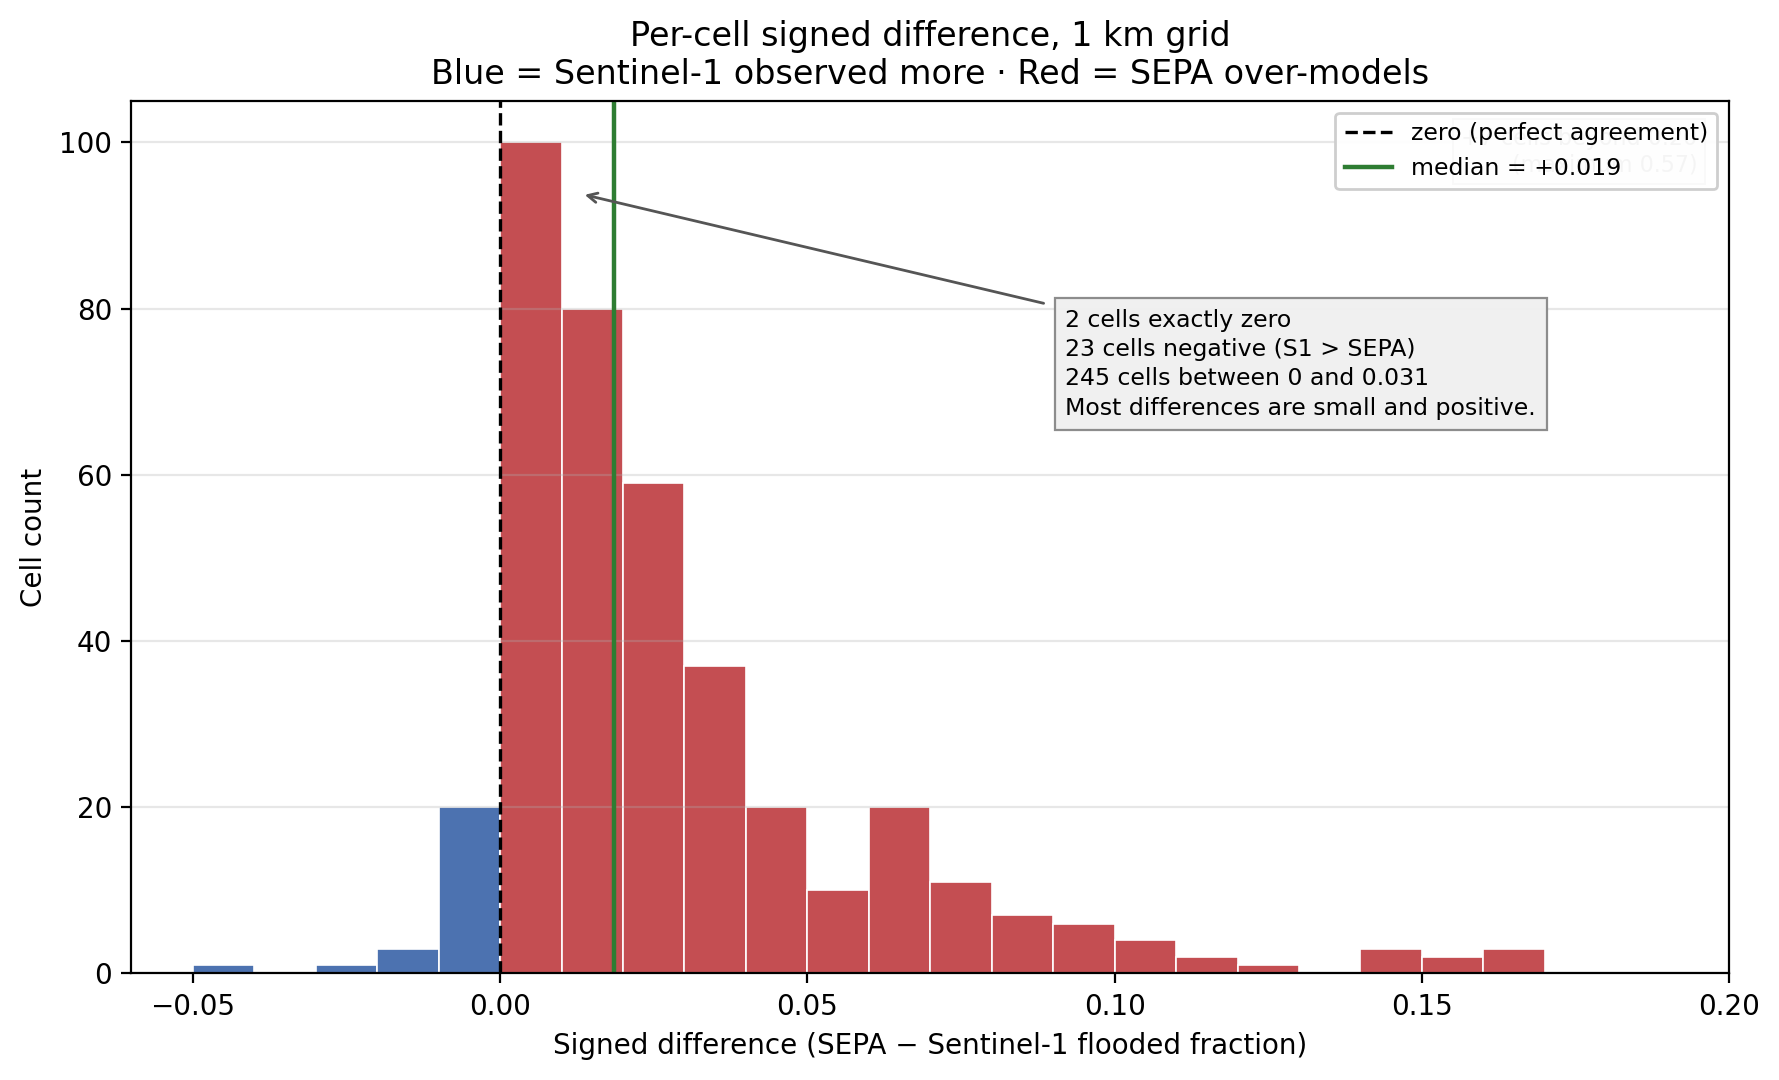

In [4]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# Read the grid written by the H1 agreement script.
gdf = gpd.read_file("h1_disagreement_grid_1km.gpkg")
print("Columns present:", list(gdf.columns))

required = {"s1_flood_frac", "sepa_flood_frac"}
missing = required - set(gdf.columns)

if missing:
    raise KeyError(
        f"Grid is missing {sorted(missing)}. "
        f"Columns available: {list(gdf.columns)}."
    )

# Drop under-sampled edge cells so that this matches the maps
# using a 25% coverage threshold.
if "n_valid_px" in gdf.columns:
    before = len(gdf)
    gdf = gdf[gdf["n_valid_px"] >= 0.25 * 10_000].copy()
    print(f"Kept {len(gdf)} of {before} cells (>=25% coverage)")

# Convention: SEPA - Sentinel-1.
# Positive values indicate that SEPA maps a larger flooded fraction.
gdf["signed_diff"] = (
    gdf["sepa_flood_frac"] - gdf["s1_flood_frac"]
)

diff = gdf["signed_diff"].dropna()

diff.to_frame("signed_diff").to_csv(
    "difference_histogram_data.csv",
    index=False
)

# Diagnostics

n_zero = int((diff == 0).sum())
n_neg = int((diff < 0).sum())
n_small_pos = int(((diff > 0) & (diff <= 0.031)).sum())
median = diff.median()
max_diff = diff.max()

print(f"n cells:                  {len(diff)}")
print(f"exactly zero:             {n_zero}")
print(f"negative:                 {n_neg}")
print(f"in (0, 0.031]:            {n_small_pos}")
print(f"median:                   {median:+.4f}")
print(f"max:                      {max_diff:+.4f}")

# Plot
XVIEW = (-0.06, 0.20)
BIN_WIDTH = 0.01

bins = np.arange(
    XVIEW[0],
    XVIEW[1] + BIN_WIDTH,
    BIN_WIDTH
)

n_beyond = int((diff > XVIEW[1]).sum())

fig, ax = plt.subplots(figsize=(9, 5.5))

# Colour bars by sign:
# blue = Sentinel-1 is larger; red = SEPA is larger.
counts, edges, patches = ax.hist(
    diff,
    bins=bins,
    edgecolor="white",
    linewidth=0.6
)

for patch, left in zip(patches, edges[:-1]):
    if left < 0:
        patch.set_facecolor("#4C72B0")
    else:
        patch.set_facecolor("#C44E52")

# Reference lines.
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="zero (perfect agreement)"
)

ax.axvline(
    median,
    color="#2E7D32",
    linestyle="-",
    linewidth=1.6,
    label=f"median = {median:+.3f}"
)

# Main callout
callout_text = (
    f"{n_zero} cells exactly zero\n"
    f"{n_neg} cells negative (S1 > SEPA)\n"
    f"{n_small_pos} cells between 0 and 0.031\n"
    "Most differences are small and positive."
)

ax.annotate(
    callout_text,
    xy=(0.012, counts.max() * 0.94),
    xytext=(0.092, counts.max() * 0.80),
    fontsize=8.5,
    linespacing=1.35,
    ha="left",
    va="top",
    bbox=dict(
        boxstyle="square,pad=0.45",
        facecolor="#F0F0F0",
        edgecolor="#888888",
        linewidth=0.8,
        alpha=0.96
    ),
    arrowprops=dict(
        arrowstyle="->",
        color="#555555",
        linewidth=1.0,
        shrinkA=4,
        shrinkB=4
    )
)

# Secondary note for observations outside the displayed range.
if n_beyond:
    ax.text(
        0.98,
        0.97,
        f"+{n_beyond} cells beyond {XVIEW[1]:.2f}\n"
        f"(maximum {max_diff:.2f})",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        color="#444444",
        bbox=dict(
            boxstyle="square,pad=0.35",
            facecolor="#F0F0F0",
            edgecolor="#999999",
            linewidth=0.7,
            alpha=0.95
        )
    )

# Labels and formatting.
ax.set_xlim(*XVIEW)
ax.set_xlabel(
    "Signed difference (SEPA − Sentinel-1 flooded fraction)"
)
ax.set_ylabel("Cell count")

ax.set_title(
    "Per-cell signed difference, 1 km grid\n"
    "Blue = Sentinel-1 observed more · Red = SEPA over-models"
)

ax.legend(
    loc="upper right",
    fontsize=8.5,
    frameon=True,
    framealpha=0.95
)

ax.grid(
    axis="y",
    alpha=0.3,
    linewidth=0.8
)

plt.tight_layout()

plt.savefig(
    "difference_histogram.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

print("Saved: difference_histogram.png")

plt.show()

In [6]:
from __future__ import annotations

from pathlib import Path

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize, TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar

# Inputs and Layout

BASE = Path("/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation")


GRID_CANDIDATES = [
    BASE / "h1_disagreement_grid_1km.gpkg",
    Path("h1_disagreement_grid_1km.gpkg"),
    BASE / "cascade_outputs" / "h1_disagreement_grid_1km.gpkg",
]


STUDY_BOUNDARY = BASE / "study_area_10Kmbuffer_dissolved.shp"

OUT_DIR = BASE
OUT_PNG_SIGNED = OUT_DIR / "h1_disagreement_signed.png"
OUT_PNG_ABSOLUTE = OUT_DIR / "h1_disagreement_absolute.png"
OUT_PNG_S1_EXCESS = OUT_DIR / "h1_disagreement_s1_excess.png"
OUT_CSV_SUMMARY = OUT_DIR / "h1_disagreement_cell_summary.csv"

TARGET_CRS = "EPSG:3035"
TARGET_EPSG = 3035

GRID_CELL_SIZE = 1000          # metres, must match GRID_CELL_SIZE in v7
PIXEL_SIZE = 10                # metres, S1 raster resolution
FULL_CELL_PX = (GRID_CELL_SIZE // PIXEL_SIZE) ** 2   # 10,000

MIN_COVERAGE = 0.25            # drop cells under 25% eligible-pixel coverage
DPI = 200
FIGSIZE = (11, 11)

SHOW_BASEMAP = True
OUTLINE_DENSE_URBAN = True

# Scale bar anchor in axes fraction. `location` still decides which corner of
# the bar is pinned; this decides where that corner sits. Raise the y value to
# lift the bar. Keep it above the CRS stamp at y=0.01 so the two do not collide.
SCALEBAR_ANCHOR = (0.98, 0.10)

COL_URBAN_OUTLINE = "#00A550"   # green: distinct from the red/blue ramp
COL_AOI = "black"
COL_CONTEXT = "#d9d9d9"


def _pos_vmax(series, q: float = 0.98) -> float:
    """
    NaN-safe positive upper bound for a sequential colour scale.

    Returns the q-quantile; if that is non-finite or <= 0 (e.g. an all-NaN or
    all-zero column), falls back to the max, and finally to a tiny positive so
    Normalize never receives NaN or 0 and silently blanks the layer.
    """
    s = series.dropna()
    if s.empty:
        return 1e-6
    v = float(s.quantile(q))
    if not np.isfinite(v) or v <= 0:
        v = float(s.max())
    return v if (np.isfinite(v) and v > 0) else 1e-6


# Colour explicit direction, verigfied at runtime 
# ColorBrewer RdBu direction as the data: negative (S1 observed more) -> blue, zero -> white, positive (SEPA over-models) -> red.
CMAP_DIVERGING = LinearSegmentedColormap.from_list(
    "BuWhRd_signed_diff",
    [
        "#053061",  # deep blue    | most negative | S1 observed far more
        "#2166ac",
        "#4393c3",
        "#92c5de",
        "#d1e5f0",
        "#f7f7f7",  # white        | zero          | agreement
        "#fddbc7",
        "#f4a582",
        "#d6604d",
        "#b2182b",
        "#67001f",  # deep red     | most positive | SEPA over-models far more
    ],
)

CMAP_MAGNITUDE = "magma_r"
CMAP_S1_EXCESS = "YlGnBu"


def verify_colour_direction(cmap, norm, probe: float) -> None:
    """
    Fail loudly if the rendered colours contradict the sign convention.

    Samples the colormap through the norm at -probe and +probe and checks that
    the negative sample is blue-dominant and the positive sample red-dominant.
    This is the guard against the specific failure that has already occurred
    here: a correct formula rendered through a reversed ramp, producing a map
    that is wrong in a way no amount of re-reading the legend will reveal.
    """
    neg_r, neg_g, neg_b, _ = cmap(norm(-probe))
    pos_r, pos_g, pos_b, _ = cmap(norm(+probe))

    if not neg_b > neg_r:
        raise ValueError(
            f"Colour direction check FAILED for negative values.\n"
            f"  signed_diff < 0 means S1 observed more than SEPA and must render BLUE,\n"
            f"  but the colormap returns RGB ({neg_r:.2f}, {neg_g:.2f}, {neg_b:.2f}).\n"
            f"  The colormap has been reversed. Do not use the output figures."
        )
    if not pos_r > pos_b:
        raise ValueError(
            f"Colour direction check FAILED for positive values.\n"
            f"  signed_diff > 0 means SEPA over-models and must render RED,\n"
            f"  but the colormap returns RGB ({pos_r:.2f}, {pos_g:.2f}, {pos_b:.2f}).\n"
            f"  The colormap has been reversed. Do not use the output figures."
        )
    print(f"  colour direction verified: "
          f"-{probe:.4f} -> blue ({neg_r:.2f},{neg_g:.2f},{neg_b:.2f}), "
          f"+{probe:.4f} -> red ({pos_r:.2f},{pos_g:.2f},{pos_b:.2f})")


# Load and validate
grid_path = next((p for p in GRID_CANDIDATES if p.exists()), None)
if grid_path is None:
    raise FileNotFoundError(
        "h1_disagreement_grid_1km.gpkg not found. Looked in:\n  "
        + "\n  ".join(str(p) for p in GRID_CANDIDATES)
        + "\nRun h1_agreement_v7.py first, or set OUT_DIR = BASE in that script "
          "so its outputs land somewhere predictable."
    )
if not STUDY_BOUNDARY.exists():
    raise FileNotFoundError(
        f"Study boundary not found:\n  {STUDY_BOUNDARY}\n"
        "This must be the same file the cascade used as VECTORS['aoi']."
    )

grid = gpd.read_file(grid_path)
print(f"Loaded {len(grid):,} grid cells from {grid_path}")
print(f"  CRS: {grid.crs}")

# A missing CRS cannot be reprojected, to_crs() raises.
if grid.crs is None:
    print(f"  [warning] no CRS on the GeoPackage; assigning {TARGET_CRS}.")
    grid = grid.set_crs(TARGET_CRS)
elif grid.crs.to_epsg() != TARGET_EPSG:
    grid = grid.to_crs(TARGET_CRS)

aoi = gpd.read_file(STUDY_BOUNDARY).to_crs(TARGET_CRS)

expected = {"s1_flood_frac", "sepa_flood_frac", "abs_diff"}
missing = expected - set(grid.columns)
if missing:
    raise KeyError(f"Grid is missing required column(s): {sorted(missing)}")

has_counts = "n_valid_px" in grid.columns
has_stratum = "stratum" in grid.columns


# Derive, Filter, Summarise
#  Positive = SEPA over-models. Negative = S1 observed more.
grid["signed_diff"] = grid["sepa_flood_frac"] - grid["s1_flood_frac"]

if has_counts:
    grid["coverage"] = grid["n_valid_px"] / FULL_CELL_PX
    n_partial = int((grid["coverage"] < MIN_COVERAGE).sum())
    print(f"\nCell coverage (eligible pixels / {FULL_CELL_PX:,} per full cell):")
    print(f"  median coverage:            {grid['coverage'].median():.2f}")
    print(f"  cells below {MIN_COVERAGE:.0%} coverage:  {n_partial:,} "
          f"({100 * n_partial / len(grid):.1f}%) - excluded from the maps")
    gplot = grid[grid["coverage"] >= MIN_COVERAGE].copy()
else:
    print("\n[note] no 'n_valid_px' column - partial edge cells cannot be filtered.")
    grid["coverage"] = np.nan
    gplot = grid.copy()

print(f"  cells mapped:               {len(gplot):,}")

# Secure if the coverage filter (or an empty grid) leaves nothing, stop here
# with a clear message rather than an opaque traceback from the quantile calls.
if gplot.empty:
    raise ValueError(
        f"No cells left to map after the {MIN_COVERAGE:.0%} coverage filter "
        f"({len(grid):,} cells loaded). Lower MIN_COVERAGE or check that the "
        "grid GeoPackage is the intended one."
    )

sd = gplot["signed_diff"].dropna()
ad = gplot["abs_diff"].dropna()

if sd.empty:
    raise ValueError("All 'signed_diff' values are NaN - nothing to plot.")

print("\nSigned difference summary (SEPA - S1):")
print(f"  n cells:  {len(sd):,}")
print(f"  min:      {sd.min():+.4f}   (S1 observed most beyond SEPA)")
print(f"  p05:      {sd.quantile(0.05):+.4f}")
print(f"  median:   {sd.median():+.4f}")
print(f"  p95:      {sd.quantile(0.95):+.4f}")
print(f"  max:      {sd.max():+.4f}   (SEPA over-models most)")
print(f"  cells where SEPA > S1 (red):   {(sd > 0).sum():,}  "
      f"({100 * (sd > 0).mean():.1f}%)")
print(f"  cells where S1 > SEPA (blue):  {(sd < 0).sum():,}  "
      f"({100 * (sd < 0).mean():.1f}%)")
print(f"  cells exactly equal (white):   {(sd == 0).sum():,}")

if has_stratum:
    print("\nBy stratum:")
    for name, sub in gplot.groupby("stratum"):
        s1_excess = int((sub["signed_diff"] < 0).sum())
        print(f"  {name:<14} n={len(sub):>4}  "
              f"median signed diff {sub['signed_diff'].median():+.4f}  "
              f"S1-excess cells {s1_excess}")

cols = [c for c in ("row", "col", "stratum", "mean_imperv", "coverage", "n_valid_px",
                    "tp", "fp", "fn", "s1_flood_frac", "sepa_flood_frac",
                    "signed_diff", "abs_diff") if c in gplot.columns]
gplot[cols].to_csv(OUT_CSV_SUMMARY, index=False)
print(f"\nCell summary: {OUT_CSV_SUMMARY}")


# Shared map furniture 
def add_colourbar(fig, ax, cmap, norm, label: str):
    """Colourbar built explicitly so the label and extent are fully controlled."""
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", shrink=0.55,
                        pad=0.03, extend="both")
    cbar.set_label(label, fontsize=10)
    return cbar


def add_scalebar(ax) -> None:
    """Scale bar, lifted clear of the CRS stamp via an explicit anchor."""
    ax.add_artist(ScaleBar(
        1, units="m", location="lower right", box_alpha=0.7,
        bbox_to_anchor=SCALEBAR_ANCHOR, bbox_transform=ax.transAxes,
    ))


def decorate(ax, title: str, extra_handles=None) -> None:
    """Boundary, basemap, scale bar, north arrow, CRS stamp, title."""
    aoi.boundary.plot(ax=ax, color=COL_AOI, linewidth=1.2, zorder=4)

    if SHOW_BASEMAP:
        try:
            ctx.add_basemap(ax, crs=TARGET_CRS,
                            source=ctx.providers.CartoDB.Positron, zoom="auto")
            for artist in ax.get_images():
                artist.set_zorder(0)
        except Exception as exc:
            print(f"  [note] basemap unavailable ({exc}); plotting without it.")
            ax.set_facecolor("#f2f2f2")
    else:
        ax.set_facecolor("#f2f2f2")

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(title, fontsize=13, pad=12)

    add_scalebar(ax)

    # Grid north, not true north: EPSG:3035 is a Lambert Azimuthal projection and
    # meridian convergence at this longitude is a few degrees. Label it honestly.
    ax.annotate(
        "", xy=(0.035, 0.975), xytext=(0.035, 0.915), xycoords="axes fraction",
        arrowprops=dict(facecolor="black", width=4, headwidth=10),
    )
    ax.text(0.035, 0.895, "grid N", transform=ax.transAxes,
            ha="center", va="top", fontsize=9, fontweight="bold")

    ax.text(0.99, 0.01, f"CRS: {TARGET_CRS}  |  1 km cells  |  "
                        f"cells <{MIN_COVERAGE:.0%} covered excluded",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8,
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=2))

    if extra_handles:
        ax.legend(handles=[h for h in extra_handles if h is not None],
                  loc="upper right", fontsize=9, framealpha=0.9)


def overlay_dense_urban(ax):
    """Outline the dense-urban cells and return a legend proxy."""
    if not (OUTLINE_DENSE_URBAN and has_stratum):
        return None
    urban = gplot[gplot["stratum"] == "dense_urban"]
    if urban.empty:
        return None
    urban.boundary.plot(ax=ax, color=COL_URBAN_OUTLINE, linewidth=1.6,
                        linestyle="--", zorder=5)
    return Line2D([0], [0], color=COL_URBAN_OUTLINE, linewidth=1.6, linestyle="--",
                  label=f"dense urban cells (n={len(urban)})")


# Figure  1 signed difference
vmax = float(np.nanmax(np.abs([sd.quantile(0.02), sd.quantile(0.98)])))
if not np.isfinite(vmax) or vmax == 0:
    vmax = float(ad.max()) if len(ad) and ad.max() > 0 else 0.01
norm_signed = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

print("\nFigure 1:")
verify_colour_direction(CMAP_DIVERGING, norm_signed, probe=vmax / 2)

faint = int((sd.abs() < vmax / 20).sum())
print(f"  stretch +/-{vmax:.4f}  ({faint:,} cells fall within 5% of white "
      f"and will be hard to see - see figure 3)")

fig, ax = plt.subplots(figsize=FIGSIZE)
gplot.plot(
    ax=ax,
    column="signed_diff",
    cmap=CMAP_DIVERGING,
    norm=norm_signed,
    edgecolor="none",
    alpha=0.85,
    zorder=2,
    legend=False,
)
add_colourbar(
    fig, ax, CMAP_DIVERGING, norm_signed,
    "\u2190  S1 observed more        SEPA \u2212 S1  flooded fraction        "
    "SEPA over-models  \u2192",
)
decorate(
    ax,
    "H1 disagreement: Sentinel-1 vs SEPA modelled flood extent\n"
    "Signed difference in flooded fraction per 1 km cell \u00b7 7\u20138 Oct 2023",
    extra_handles=[overlay_dense_urban(ax)],
)
fig.savefig(OUT_PNG_SIGNED, dpi=DPI, bbox_inches="tight")
plt.close(fig)
print(f"  saved: {OUT_PNG_SIGNED}")


# Figure 2 - Absolute Difference 
norm_abs = Normalize(vmin=0, vmax=_pos_vmax(ad))

fig, ax = plt.subplots(figsize=FIGSIZE)
gplot.plot(
    ax=ax,
    column="abs_diff",
    cmap=CMAP_MAGNITUDE,
    norm=norm_abs,
    edgecolor="none",
    alpha=0.85,
    zorder=2,
    legend=False,
)
add_colourbar(
    fig, ax, CMAP_MAGNITUDE, norm_abs,
    "|SEPA \u2212 S1|  flooded fraction   (darker = more disagreement, direction not shown)",
)
decorate(
    ax,
    "H1 disagreement: absolute difference per 1 km cell\n"
    "Sentinel-1 vs SEPA modelled flood extent \u00b7 7\u20138 Oct 2023",
    extra_handles=[overlay_dense_urban(ax)],
)
fig.savefig(OUT_PNG_ABSOLUTE, dpi=DPI, bbox_inches="tight")
plt.close(fig)
print(f"\nFigure 2 saved: {OUT_PNG_ABSOLUTE}")


# FIGURE 3  S1 excess only  
# Where Sentinel-1 observed flooding that SEPA does not model. On the diverging
# map these cells sit in the compressed negative tail and read as near-white.
excess = gplot[gplot["signed_diff"] < 0].copy()
excess["s1_excess"] = -excess["signed_diff"]      # positive magnitude for plotting

if excess.empty:
    print("\n[note] no cells with S1 > SEPA - figure 3 skipped.")
else:
    print(f"\nFigure 3: {len(excess):,} cells where S1 > SEPA "
          f"(max excess {excess['s1_excess'].max():.4f})")
    if has_stratum:
        share = (excess["stratum"] == "dense_urban").mean()
        print(f"  {100 * share:.1f}% of them are dense-urban cells")

    norm_excess = Normalize(vmin=0, vmax=_pos_vmax(excess["s1_excess"]))

    fig, ax = plt.subplots(figsize=FIGSIZE)
    gplot.plot(ax=ax, color=COL_CONTEXT, edgecolor="none", alpha=0.55, zorder=1)
    excess.plot(
        ax=ax,
        column="s1_excess",
        cmap=CMAP_S1_EXCESS,
        norm=norm_excess,
        edgecolor="none",
        alpha=0.95,
        zorder=2,
        legend=False,
    )
    add_colourbar(
        fig, ax, CMAP_S1_EXCESS, norm_excess,
        "S1 \u2212 SEPA  flooded fraction   "
        "(observed flooding absent from the SEPA model)",
    )
    handles = [
        Line2D([0], [0], marker="s", color="none", markerfacecolor=COL_CONTEXT,
               markersize=10, label="other eligible cells"),
        overlay_dense_urban(ax),
    ]
    decorate(
        ax,
        "H1 disagreement: flooding observed by Sentinel-1 but not modelled by SEPA\n"
        "Cells where the S1 flooded fraction exceeds SEPA \u00b7 7\u20138 Oct 2023",
        extra_handles=handles,
    )
    fig.savefig(OUT_PNG_S1_EXCESS, dpi=DPI, bbox_inches="tight")
    plt.close(fig)
    print(f"  saved: {OUT_PNG_S1_EXCESS}")

print("\nDone.")

Loaded 481 grid cells from /Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/h1_disagreement_grid_1km.gpkg
  CRS: EPSG:3035

Cell coverage (eligible pixels / 10,000 per full cell):
  median coverage:            0.88
  cells below 25% coverage:  84 (17.5%) - excluded from the maps
  cells mapped:               397

Signed difference summary (SEPA - S1):
  n cells:  397
  min:      -0.0474   (S1 observed most beyond SEPA)
  p05:      -0.0008
  median:   +0.0186
  p95:      +0.1046
  max:      +0.5720   (SEPA over-models most)
  cells where SEPA > S1 (red):   372  (93.7%)
  cells where S1 > SEPA (blue):  23  (5.8%)
  cells exactly equal (white):   2

By stratum:
  dense_urban    n=   6  median signed diff +0.0097  S1-excess cells 3
  less_built_up  n= 391  median signed diff +0.0186  S1-excess cells 20

Cell summary: /Users/xrysa/Desktop/MSc_in_Urban_Analytics/Dissertation/h1_disagreement_cell_summary.csv

Figure 1:
  colour direction verified: -0.0836 -> blue (0.42,0.68,0.82), +0.

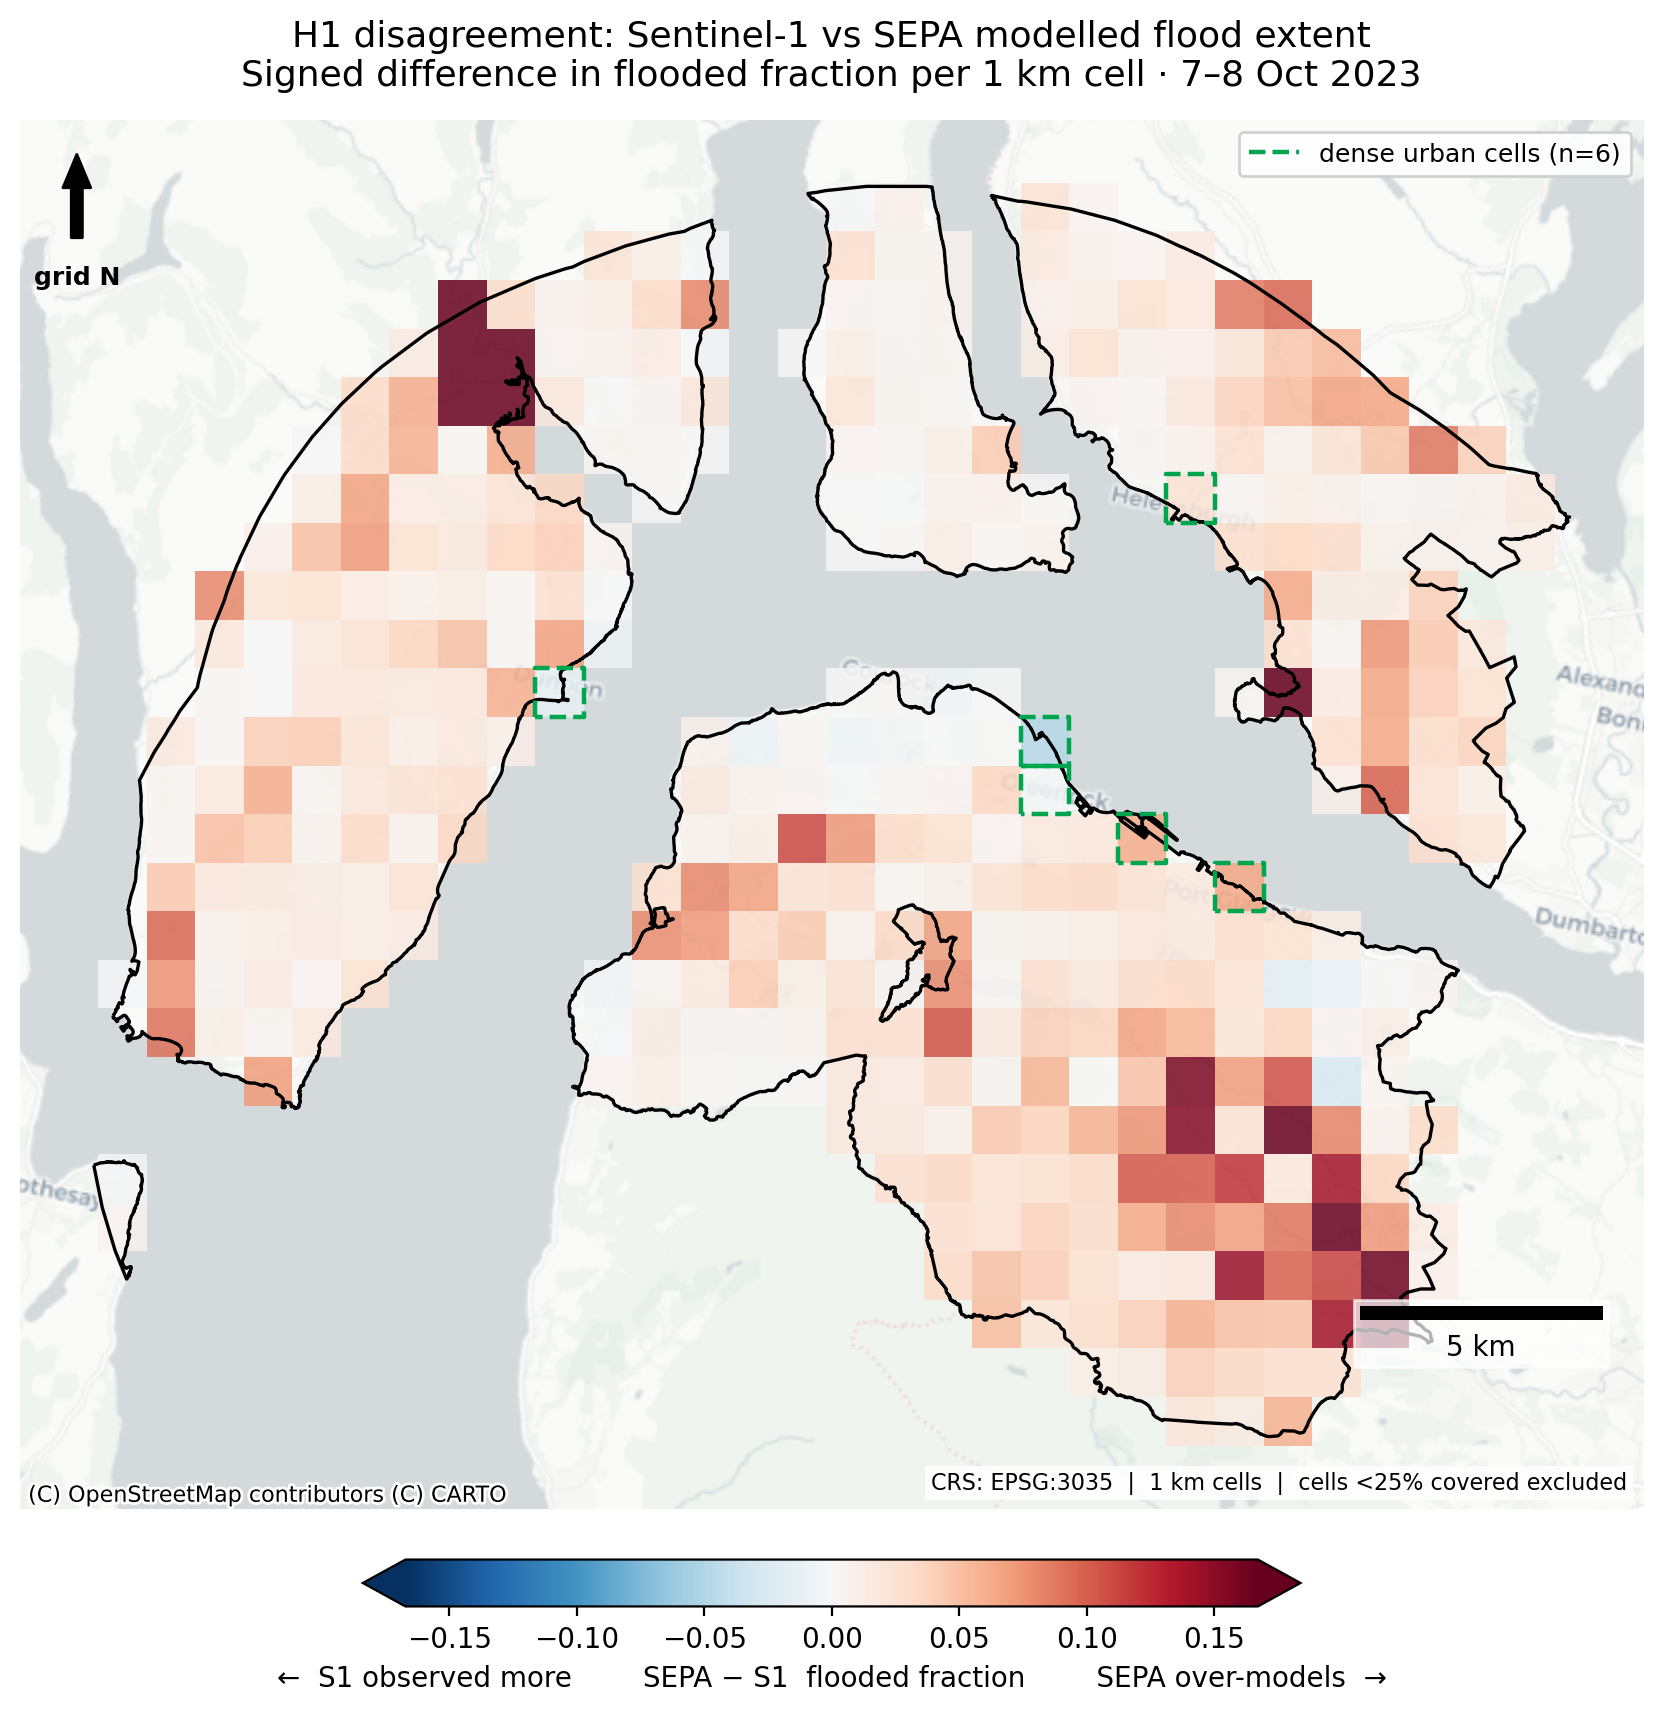

In [7]:
from IPython.display import Image
Image("h1_disagreement_signed.png")

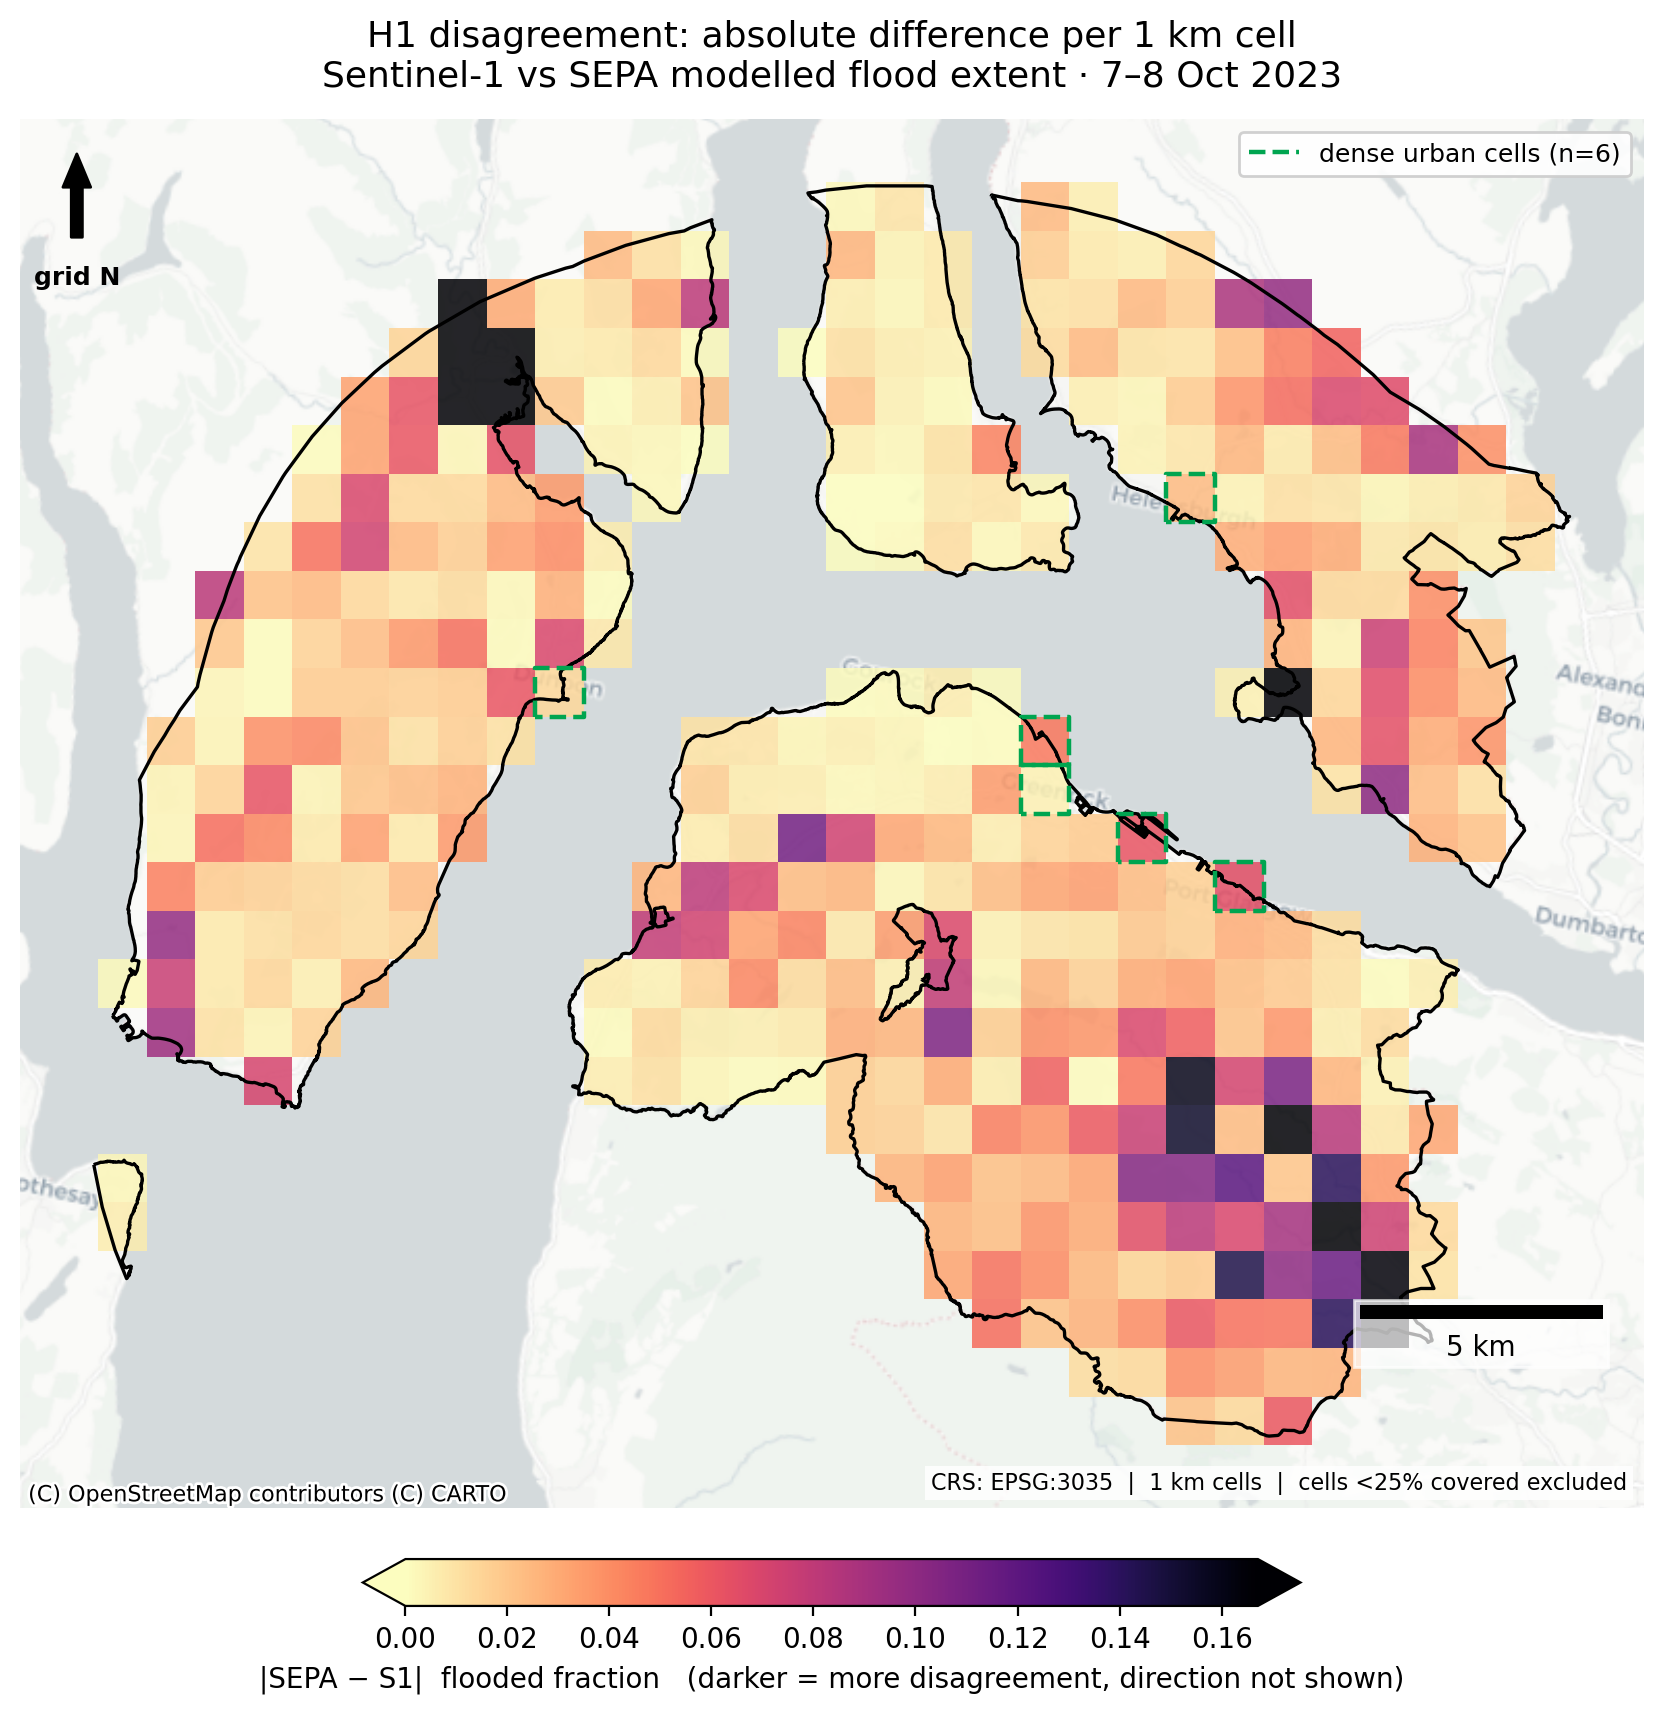

In [8]:
from IPython.display import Image
Image("h1_disagreement_absolute.png")